# 05 · Test evaluation

Evaluate the champion (focal+dice, seed 42) on the held-out test split. Test has
been untouched since notebook 01, so this is an honest estimate of performance on
unseen data. The rule is one evaluation, on the already-chosen model: test is not
used to select anything, and whatever comes out is reported as is.

This evaluates the current champion. It is not the project's final result, since
DeepLabV3+ is still to be tried. The error analysis here motivates that next step.

## Quantitative result

Load the saved checkpoint into the same architecture and run the test split at
full resolution, no crop, as in validation. The criterion is only there for the
evaluate() signature; its loss on test is meaningless, only the IoU matters.

In [2]:
from pathlib import Path

import torch
from torch.utils.data import DataLoader

from cropweed_seg.dataset import PeanutDataset
from cropweed_seg.engine import evaluate
from cropweed_seg.losses import build_criterion
from cropweed_seg.metrics import ConfusionMatrixMetric
from cropweed_seg.model import build_model
from cropweed_seg.transforms import build_transforms

ROOT = Path.cwd().parent
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)

# Load the champion: focal+dice, seed 42
model = build_model().to(device)
checkpoint = ROOT / "runs" / "focal_dice_s42" / "model.pt"
model.load_state_dict(torch.load(checkpoint, map_location=device))
print(f"loaded champion from {checkpoint}")

# Test split, evaluated at full resolution (no crop), as in val
test_loader = DataLoader(
    PeanutDataset(ROOT, "test", build_transforms("test")),
    batch_size=4, shuffle=False,
)

# criterion only needed for evaluate()'s signature; the loss value on test
# is not meaningful, only the IoU is
criterion = build_criterion("focal_dice")
metric = ConfusionMatrixMetric()

_, test_iou = evaluate(model, test_loader, criterion, metric, device)

print("\nTEST results (champion, focal+dice):")
for k, v in test_iou.items():
    print(f"  {k:<16} {v:.4f}")
print("\nVAL was: weed 0.670, mIoU 0.849")

loaded champion from /Users/alexmunozestornell/Documents/Personal Projects/Alex's Projects/cropweed-seg/runs/focal_dice_s42/model.pt

TEST results (champion, focal+dice):
  iou_background   0.9711
  iou_crop         0.9096
  iou_weed         0.6695
  miou             0.8500

VAL was: weed 0.670, mIoU 0.849


Test matches validation almost exactly: weed 0.670 against 0.670, mIoU 0.850
against 0.849. No drop from val to test, so the estimate is reliable and not an
artifact of the particular split. The close match also validates the method in
hindsight: stratified split, selection on validation, seeds, and leaving test
untouched until now. A methodology mistake would usually show up as divergence
here.

Per-class test IoU: background 0.971, crop 0.910, weed 0.670. weed sits well
below the other two, consistent with Tran & Phan reporting weed as the harder
class.

## Per-image weed IoU

To find where the model fails, compute weed IoU per image and rank worst-first.
weed is present in every image (notebook 01), so there are no undefined values
here. The worst cases are the ones worth dissecting.

In [3]:
import numpy as np

from cropweed_seg.masks import index_mask_to_rgb

test_ds = PeanutDataset(ROOT, "test", build_transforms("test"))
test_stems = (ROOT / "data" / "splits" / "test.txt").read_text().split()


def weed_iou_single(pred: torch.Tensor, target: torch.Tensor) -> float:
    """Weed IoU for one image. Returns NaN if weed is absent from both."""
    pred_w = pred == 2
    targ_w = target == 2
    inter = (pred_w & targ_w).sum().item()
    union = (pred_w | targ_w).sum().item()
    return inter / union if union > 0 else float("nan")


model.eval()
per_image = []
with torch.no_grad():
    for idx in range(len(test_ds)):
        image, mask = test_ds[idx]
        logits = model(image.unsqueeze(0).to(device))
        pred = logits.argmax(dim=1).squeeze(0).cpu()
        per_image.append({
            "stem": test_stems[idx],
            "weed_iou": weed_iou_single(pred, mask),
            "idx": idx,
        })

# Sort worst-first by weed IoU; weed is present in every image, so no NaN here
ranked = sorted(per_image, key=lambda r: r["weed_iou"])
print("Worst 5 by weed IoU:")
for r in ranked[:5]:
    print(f"  {r['stem']}: weed IoU {r['weed_iou']:.3f}")
print("\nBest 5 by weed IoU:")
for r in ranked[-5:]:
    print(f"  {r['stem']}: weed IoU {r['weed_iou']:.3f}")

Worst 5 by weed IoU:
  0376: weed IoU 0.355
  0107: weed IoU 0.360
  0010: weed IoU 0.376
  0272: weed IoU 0.384
  0221: weed IoU 0.418

Best 5 by weed IoU:
  0310: weed IoU 0.776
  0146: weed IoU 0.782
  0364: weed IoU 0.808
  0327: weed IoU 0.816
  0349: weed IoU 0.855


The spread is wide, from 0.355 on the worst image to 0.855 on the best. The worst
cases are what the gallery examines next.

## Error gallery

For each of the worst cases: image, ground truth, prediction, and a weed error
map. The error map separates the two failure types, teal for missed weed (false
negative) and orange for hallucinated weed (false positive). Which color
dominates tells the character of the error, which a single IoU number cannot.

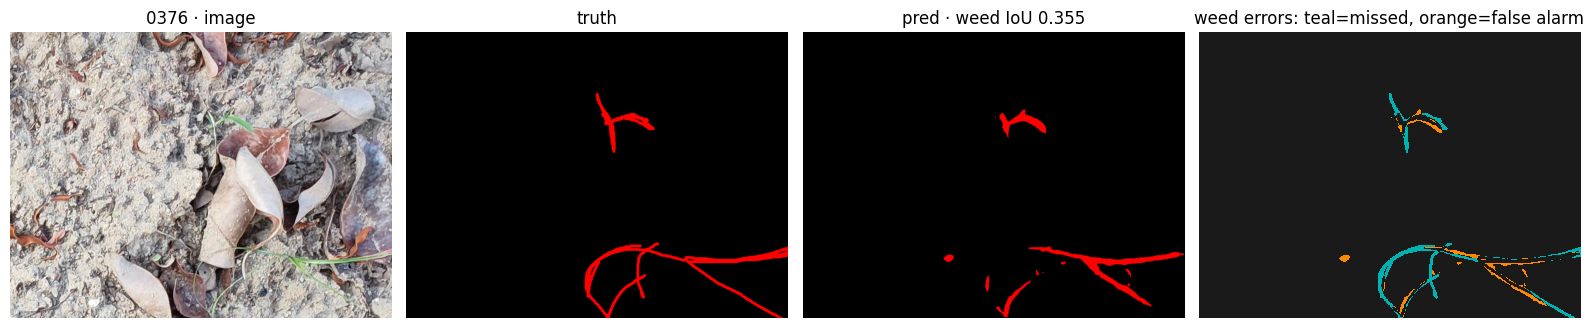

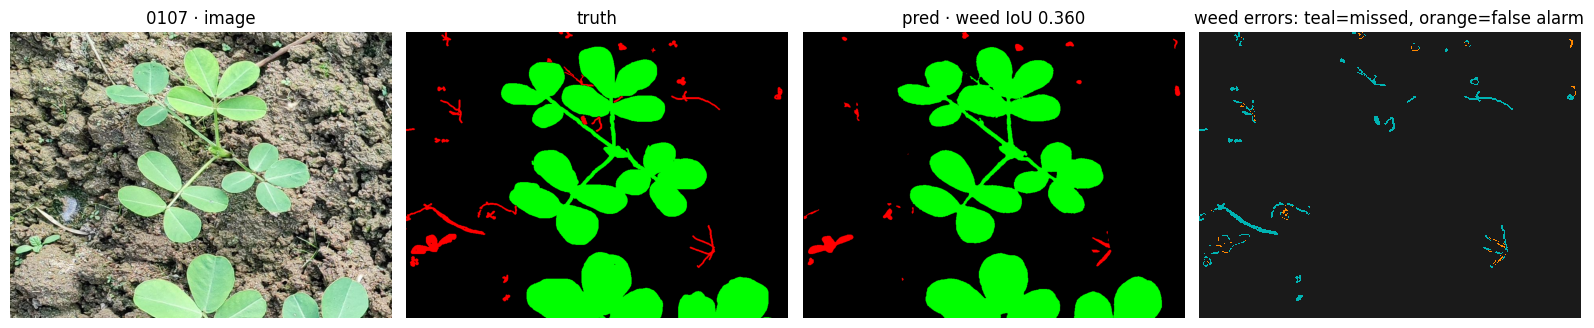

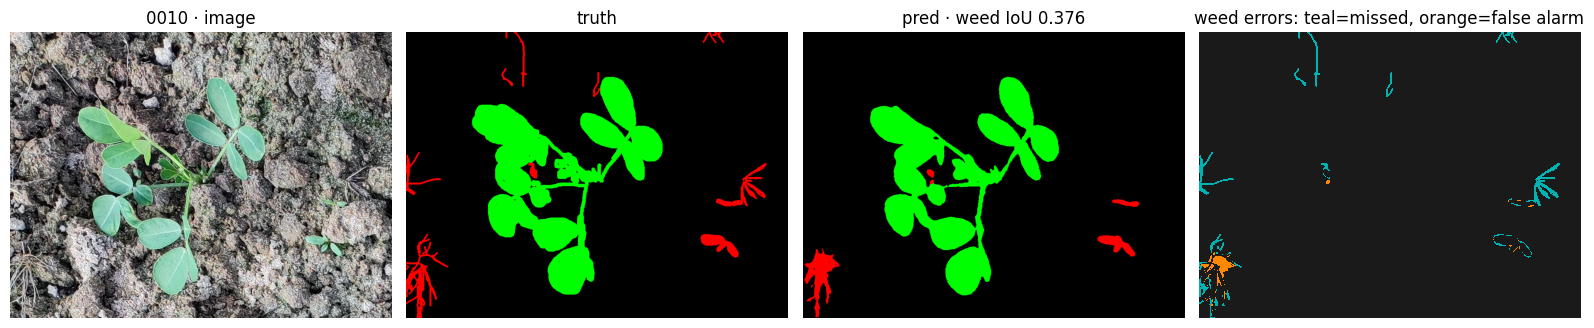

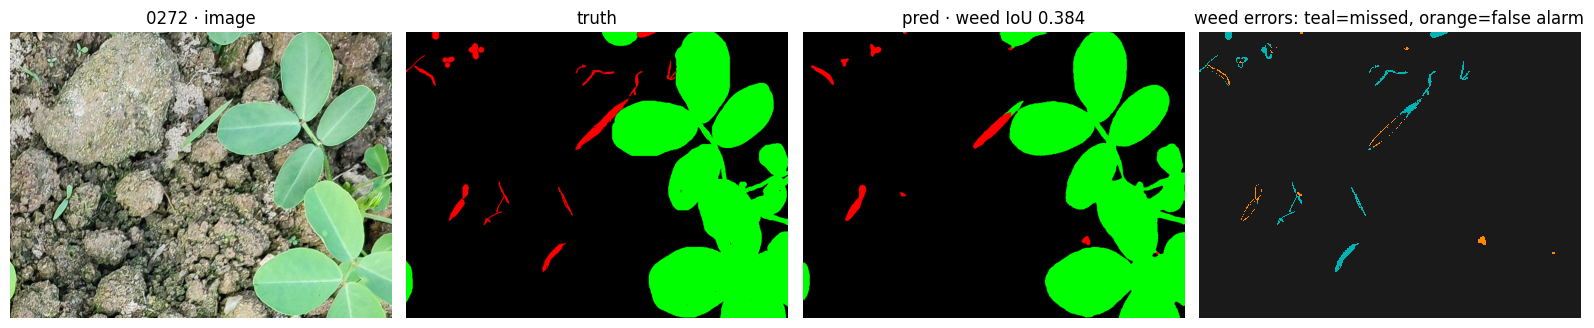

In [4]:
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap

INDEX_CMAP = ListedColormap(["black", "lime", "red"])
# error map palette: correct / false negative / false positive
ERR_CMAP = ListedColormap(["#1a1a1a", "#00b3b3", "#ff8800"])

mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)


def show_case(rec):
    image, mask = test_ds[rec["idx"]]
    with torch.no_grad():
        pred = model(image.unsqueeze(0).to(device)).argmax(dim=1).squeeze(0).cpu()

    img_vis = (image * std + mean).clamp(0, 1).permute(1, 2, 0)

    # weed error map: 0 correct, 1 false negative (missed weed), 2 false positive
    targ_w, pred_w = (mask == 2), (pred == 2)
    err = torch.zeros_like(mask)
    err[targ_w & ~pred_w] = 1   # missed weed
    err[~targ_w & pred_w] = 2   # hallucinated weed

    fig, ax = plt.subplots(1, 4, figsize=(16, 4))
    ax[0].imshow(img_vis); ax[0].set_title(f"{rec['stem']} · image")
    ax[1].imshow(index_mask_to_rgb(mask.numpy())); ax[1].set_title("truth")
    ax[2].imshow(index_mask_to_rgb(pred.numpy())); ax[2].set_title(f"pred · weed IoU {rec['weed_iou']:.3f}")
    ax[3].imshow(err, cmap=ERR_CMAP, vmin=0, vmax=2, interpolation="nearest")
    ax[3].set_title("weed errors: teal=missed, orange=false alarm")
    for a in ax:
        a.axis("off")
    plt.tight_layout()
    plt.show()


for rec in ranked[:4]:
    show_case(rec)

## What the errors show

Across the worst cases the pattern is consistent. Teal dominates: the model misses
weed rather than hallucinating it. The missed weed is thin, filamentous, and
low-contrast against pale soil and leaf litter. Compact weed and the large crop
leaves are segmented well. Where the model does catch a thin weed, it places the
boundary imprecisely, which shows as orange edges alongside teal.

The failure is detection and boundary precision on fine structures, not confusion
between classes. A 2 to 3 pixel stem barely survives the encoder's downsampling,
so the information is lost in the architecture rather than misunderstood. This is
a resolution limit of U-Net, not a problem with the class-imbalance strategy,
which means more class weighting or loss tuning would not help.

This points to the next experiment with a concrete hypothesis: DeepLabV3+, with
its decoder and atrous convolutions designed to preserve fine detail, should
recover some of the thin weed that U-Net loses. Higher input resolution is the
other lever. Both are tested against the focal+dice champion (test weed 0.670).